# What the experimental excess is

The nu-classifier scores about 1,500 more experimental events above 0.8 than the atmospheric
muon simulation accounts for — twice what it predicts at a fixed event shape. This
notebook identifies them.

**Conclusion in five lines.** The bulk of the excess is the classifier's own failure mode
appearing on real data: it matches the muons the model misreads on every measured axis and
matches genuine neutrinos on none. The failure is geometric — the decision boundary sits at
the horizon because in the simulation "neutrino" and "up-going" coincide without exception.
What the simulation gets wrong is light, not rate or shape: at matched hit count its events
carry 1.4x less charge. Known atmospheric neutrinos cannot account for the bulk. Fourteen
events in an elongated corner remain undecided, and no direction measurement exists to settle
them.

**The order of argument is deliberate.** §3 asks what these events *are*, from their own
measured properties, using no flux, no exposure and no assumption that the muon simulation is
right in rate. Counting appears only in §7, in the narrow role it can fill. The reverse order
would be a trap: "too many to be neutrinos" presumes the muon prediction it is measured
against, and is powerless against a population whose flux is unknown — the hypothesis most
worth keeping open.

**Data.** 29 experimental runs from season 2020, clusters 2 to 7, converted in `exp_full.h5`;
two runs excluded for a measured detector fault (§4). **Model**
`260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256`, epoch 23 — the first
training run whose Monte Carlo source and experimental target were selected with the same
sig-noise batch size, which matters because that batch size decides which hits count as
signal (`doc/sig_noise_batch_size.md`).

**Re-running.** Read-only; every table was written by the build scripts in this directory
(§A.3). `jupyter nbconvert --to notebook --execute --inplace excess.ipynb`, about ten minutes.
Statuses `verified` / `consistent` / `refuted` follow `doc/claims_log.md`.


## 1. Definitions, sample, exposure

Everything the rest of the notebook needs, in one place.

In [1]:
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT  = Path("/home/albert/Baikal2025")
MODEL = "260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256@best_da_model"
PREDS = ROOT / "inference_v2/nu_classifier/preds" / MODEL

db = duckdb.connect(str(PREDS / "mc_merged_thr0p8.duckdb"), read_only=True)
db.execute(f"ATTACH '{PREDS / 'exp_full_thr0p8.duckdb'}' AS exp (READ_ONLY)")
db.execute("SET enable_progress_bar = false")   # keeps the notebook output clean
query = lambda sql: db.execute(sql).df()

# The selection, written once. Every query joins `splits`, so an event the model trained on,
# or an event from a run excluded for a measured fault, cannot enter a number by accident.
QUALITY   = "p.n_sn_hits >= 8 AND p.n_sn_strings >= 3"      # the project's "h8s3" cut
MC_SEL    = f"{QUALITY} AND NOT s.used_for_labels"
EXP_SEL   = f"{QUALITY} AND NOT s.excluded"
MUONS     = f"{MC_SEL} AND s.data_class = 'muatm_2020'"
NEUTRINOS = f"{MC_SEL} AND s.data_class IN ('nuatm_2020','nue2_2020')"
HIGH      = "p.score > 0.8"

# Reference categorical palette, fixed order, CVD-validated: OKLab dE >= 9.2 under simulated
# protan/deutan, >= 27.6 for normal vision. Aqua is below the contrast target, so every
# series is direct-labelled and every figure is duplicated as a table.
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"

def style(ax):
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", linewidth=0.8); ax.set_axisbelow(True)
    for side in ("top", "right"): ax.spines[side].set_visible(False)
    for side in ("left", "bottom"): ax.spines[side].set_color("#c9c8c3")
    ax.tick_params(colors=MUTED, length=0)
    return ax

### 1.1 The cut-flow

What each cut removes, for every population. `h8s3` means at least 8 signal hits on at least
3 strings, where "signal" is a hit the sig-noise network gives probability above 0.8; it is
the project's standard quality cut and the level at which the classifier was trained and
evaluated.

In [2]:
def cut_flow(label, prefix, klass=None):
    klass_clause = f" AND s.data_class = '{klass}'" if klass else ""
    exclusion = ("NOT s.used_for_labels" if prefix == "" else "NOT s.excluded")
    return f"""
    SELECT '{label}' AS population,
           count(*) AS scored,
           count(*) FILTER (WHERE {QUALITY}) AS after_h8s3,
           count(*) FILTER (WHERE {QUALITY} AND {exclusion}) AS after_exclusions,
           count(*) FILTER (WHERE {QUALITY} AND {exclusion} AND {HIGH}) AS score_above_0p8
    FROM {prefix}predictions p JOIN {prefix}splits s USING (event_fk)
    WHERE TRUE{klass_clause}"""

flow = query(" UNION ALL ".join([
    cut_flow("MC muons (muatm)",        "", "muatm_2020"),
    cut_flow("MC atm. neutrinos",       "", "nuatm_2020"),
    cut_flow("MC astro. neutrinos",     "", "nue2_2020"),
    cut_flow("experimental",            "exp."),
]))
display(flow)
print("MC exclusion removes events the model trained on; experimental exclusion removes the "
      "two runs with the detector fault of §4.")

,population,scored,after_h8s3,after_exclusions,score_above_0p8
0,MC muons (muatm),75825013,23171597,23167718,7751
1,MC atm. neutrinos,13929541,586664,531066,525904
2,MC astro. neutrinos,4608785,1920607,1373194,1360695
3,experimental,8231582,3353716,3180681,3044


MC exclusion removes events the model trained on; experimental exclusion removes the two runs with the detector fault of §4.


In [3]:
exposure = query("""
    SELECT count(*) AS runs, round(sum(run_hours), 1) AS total_hours,
           round(avg(run_hours), 1) AS mean_run_hours
    FROM (SELECT s.part_key,
                 (max(t.timestamp_ns) - min(t.timestamp_ns)) / 1e9 / 3600 AS run_hours
          FROM exp.event_time t JOIN exp.splits s USING (event_fk)
          WHERE NOT s.excluded GROUP BY 1)
""")
display(exposure)
EXPOSURE_HOURS = float(exposure.total_hours.iloc[0])
n_exp_quality = int(flow.loc[flow.population == "experimental", "after_exclusions"].iloc[0])
print(f"{n_exp_quality:,} quality events in {EXPOSURE_HOURS:.1f} h "
      f"= {n_exp_quality/EXPOSURE_HOURS/3600:.2f} Hz of quality events")

,runs,total_hours,mean_run_hours
0,27,604.9,22.4


3,180,681 quality events in 604.9 h = 1.46 Hz of quality events


### 1.2 Quantities

Every derived quantity used below, defined before first use. All are per event, computed from
the signal hits only (sig-noise probability above 0.8) and stored by `compute_scalars.py`;
`test_scalars.py` checks each against a hand-computed four-hit event.

| quantity | definition | units |
|---|---|---|
| `n_sig_hits` | number of signal hits | count |
| `n_channels` | distinct optical modules among them | count |
| `n_sig_strings` | distinct strings, from `channel // 36` | count |
| `hits per module` | `n_sig_hits / n_channels`; above 1.2 means modules hit repeatedly | — |
| `q_total`, `q_max` | summed / largest hit charge, each hit clipped at 100 p.e. | p.e. |
| `z_span`, `xy_span` | extent of the hit cloud in depth / horizontally | m |
| `t_span` | last hit time minus first | ns |
| **`r_vert`** | `σ_z / √(σ_x² + σ_y²)` — **aspect ratio of the hit cloud, not an angle**; see §6 | — |
| `track_likeness` | `r²` of hit time against depth: 1 = hits on a line, as a track gives | — |
| `distance_to_nu`, `distance_to_mu` | mean distance to the 20 nearest neighbours in a neutrino-only / muon-only reference set of MC embeddings | — |

The 100 p.e. clip on charge is the same bound the classifier applies internally, so `q_total`
describes the event the network actually saw.

`distance_to_*` uses a reference of 188,472 MC events drawn 2:1:1 (muons : atmospheric ν :
astrophysical ν) from parts reserved for the purpose, so no event is ever compared against a
manifold built from its own part. These distances **do not converge** with reference size
(§A.2) — only comparisons at a fixed reference are meaningful.

### 1.3 The one assumption behind every ratio

There is no absolute normalisation available: the muon simulation carries `event_weight`
identically 1 and no generated livetime is recorded anywhere (§A.1). Each population is
therefore normalised to its **own** quality-cut count, which is exact only if the quality
sample is muon-dominated in both simulation and data.

That is checkable in the model's own representation — and it holds:

In [4]:
display(query(f"""
    SELECT 'MC muons, score <= 0.8' AS population, count(*) AS events,
           round(median(d.distance_to_mu), 2) AS to_muon_manifold,
           round(median(d.distance_to_nu), 2) AS to_neutrino_manifold
    FROM predictions p JOIN splits s USING (event_fk) JOIN distances d USING (event_fk)
    WHERE {MUONS} AND NOT {HIGH}
    UNION ALL
    SELECT 'experimental, score <= 0.8', count(*),
           round(median(d.distance_to_mu), 2), round(median(d.distance_to_nu), 2)
    FROM exp.predictions p JOIN exp.splits s USING (event_fk)
    JOIN exp.distances d USING (event_fk) WHERE {EXP_SEL} AND NOT {HIGH}
"""))
print("The bulk of the experimental sample sits on the muon manifold — 0.72 away against "
      "0.59 for\nsimulated muons — and 9.10 from the neutrino manifold. It is muons, and the "
      "assumption holds.\n\n"
      "The 0.13 gap between the two is the residual mismatch between simulation and data in "
      "this\nembedding. It is worth noting and it is small: the distances that carry the "
      "argument below\nare 3.8 and 6.2, forty times larger.")

,population,events,to_muon_manifold,to_neutrino_manifold
0,"MC muons, score <= 0.8",200000,0.59,8.95
1,"experimental, score <= 0.8",200000,0.72,9.10


The bulk of the experimental sample sits on the muon manifold — 0.72 away against 0.59 for
simulated muons — and 9.10 from the neutrino manifold. It is muons, and the assumption holds.

The 0.13 gap between the two is the residual mismatch between simulation and data in this
embedding. It is worth noting and it is small: the distances that carry the argument below
are 3.8 and 6.2, forty times larger.


### 1.4 What "the excess" names — and what it cannot

Throughout, **the excess** is a surplus in *counts*: more experimental events pass `score > 0.8`
than the muon simulation predicts. It is not a set of events. Of the 3,044 experimental events
above the threshold, about 1,546 are the predicted muon background and about 1,498 are surplus
— but **no individual event can be assigned to either**, because nothing distinguishes a
misread muon in the data from whatever else may be there.

This governs how the figures may be read. Where a figure plots "experimental events scored
> 0.8" it plots both components at once, so any statement about the surplus alone is an
inference about the *mixture*: were the surplus half a different kind of event, the combined
population would betray it as a second component — a displacement, a second lobe, or a
broadening relative to the misread simulated muons. That is the form the argument takes in
figures 1 and 2, and the wording says "high-scoring experimental events" wherever that is what
is drawn.

## 2. The observation

How many excess events there are, how significant that is, and whether it depends on where
the score threshold is put.

In [ ]:
SHAPE_BANDS = [(0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.2), (1.2, 99)]

def band_counts(prefix, low, high, threshold, extra=""):
    exclusion = "NOT s.used_for_labels" if prefix == "" else "NOT s.excluded"
    klass = " AND s.data_class = 'muatm_2020'" if prefix == "" else ""
    return query(f"""
        SELECT count(*) AS quality, count(*) FILTER (WHERE p.score > {threshold}) AS selected
        FROM {prefix}predictions p JOIN {prefix}splits s USING (event_fk)
        JOIN {prefix}scalars sc USING (event_fk)
        WHERE {QUALITY} AND {exclusion}{klass}
          AND sc.r_vert >= {low} AND sc.r_vert < {high}{" AND " + extra if extra else ""}""").iloc[0]

def excess_at(threshold, extra=""):
    """Predicted and observed counts, summed over shape bands.

    Summing per band rather than scaling globally, because the two samples do not have the
    same shape composition (next cell) — a single global rate would mis-predict.
    """
    observed = predicted = variance = 0.0
    for low, high in SHAPE_BANDS:
        mc = band_counts("", low, high, threshold, extra)
        ex = band_counts("exp.", low, high, threshold, extra)
        if mc.selected == 0 or ex.quality == 0:
            continue
        band_prediction = ex.quality * mc.selected / mc.quality
        observed += ex.selected
        predicted += band_prediction
        variance += ex.selected + (band_prediction / np.sqrt(mc.selected)) ** 2
    return observed, predicted, np.sqrt(variance)

rows = []
for threshold in (0.8, 0.9, 0.95, 0.99):
    observed, predicted, error = excess_at(threshold)
    rows.append(dict(threshold=threshold, observed=int(observed), predicted=round(predicted, 1),
                     excess=round(observed - predicted, 1), uncertainty=round(error, 1),
                     sigma=round((observed - predicted) / error, 1),
                     ratio=round(observed / predicted, 2)))
sensitivity = pd.DataFrame(rows)
display(sensitivity)
EXCESS_AT_0P8 = float(sensitivity.loc[sensitivity.threshold == 0.8, "excess"].iloc[0])
print(f"At the working threshold of 0.8: {EXCESS_AT_0P8:.0f} excess events "
      f"in {EXPOSURE_HOURS:.0f} hours.")

,threshold,observed,predicted,excess,uncertainty,sigma,ratio
0,0.80,3044,1545.8,1498.2,58.1,25.8,1.97
1,0.90,1386,641.7,744.3,39.0,19.1,2.16
2,0.95,732,302.4,429.6,28.2,15.2,2.42
3,0.99,104,30.6,73.4,10.5,7.0,3.39


At the working threshold of 0.8: 1498 excess events in 605 hours.


In [6]:
# Why the prediction is built per band: the two samples are not composed alike, and this is
# true before the classifier is consulted at all.
rows = []
mc_total = int(query(f"""SELECT count(*) n FROM predictions p JOIN splits s USING(event_fk)
    WHERE {MUONS}""").n.iloc[0])
exp_total = n_exp_quality
for low, high in SHAPE_BANDS:
    mc, ex = band_counts("", low, high, 1.1), band_counts("exp.", low, high, 1.1)
    rows.append(dict(r_vert=f"{low}-{high}", mc_events=int(mc.quality),
                     mc_share_pct=round(100 * mc.quality / mc_total, 2),
                     exp_events=int(ex.quality),
                     exp_share_pct=round(100 * ex.quality / exp_total, 2),
                     ratio=round((ex.quality / exp_total) / (mc.quality / mc_total), 2)))
display(pd.DataFrame(rows))
print("The data holds twice the share of flat wide patterns and fewer tall ones, so the "
      "simulation\nis already wrong in composition before any score is applied. That makes "
      "two distinct\ndiscrepancies, which compound:\n"
      "   1. composition — the quality sample itself is shaped differently\n"
      "   2. rate — within a fixed shape, the data holds about twice as many high-score events\n\n"
      "Scaling globally mixes the two: 1,980 excess events at a ratio of 2.9. Scaling per band\n"
      "isolates the second: 1,498 at a ratio of 2.0, the conservative figure used from here on.")


,r_vert,mc_events,mc_share_pct,exp_events,exp_share_pct,ratio
0,0-0.4,221885,0.96,62887,1.98,2.06
1,0.4-0.6,1777645,7.67,370459,11.65,1.52
2,0.6-0.8,3724625,16.08,581980,18.30,1.14
3,0.8-1.2,7506262,32.40,1018628,32.03,0.99
4,1.2-99,9937301,42.89,1146727,36.05,0.84


The data holds twice the share of flat wide patterns and fewer tall ones, so the simulation
is already wrong in composition before any score is applied. That makes two distinct
discrepancies, which compound:
   1. composition — the quality sample itself is shaped differently
   2. rate — within a fixed shape, the data holds about twice as many high-score events

Scaling globally mixes the two: 1,980 excess events at a ratio of 2.9. Scaling per band
isolates the second: 1,498 at a ratio of 2.0, the conservative figure used from here on.


The excess is present at every threshold and grows in relative terms as the threshold
tightens — 2.0x at 0.8 rising to 3.4x at 0.99 — so it is not an artefact of where the cut was
put.

The quoted significances are **purely statistical** and are not the limitation here: at 26
sigma the Poisson error is 4% while the choice of how to build the prediction moves the answer
by 25% (previous cell). Statistics settle that something is there; they say nothing about what
it is, which is the rest of this notebook.

## 3. What are these events?

The identification. Four populations compared on properties measured from the hits
themselves. No flux, no exposure and no simulation rate enters here, so nothing in this
section can be overturned by revising any of them.

**The obvious objection first.** Both high-scoring populations are selected by the same
classifier at the same threshold, and the second table below compares them in that
classifier's own representation. Would any two populations selected that way not coincide by
construction?

No, and the table answers it: MC neutrinos are selected by the same classifier at the same
threshold and land nowhere near — 0.38 from the neutrino manifold against 3.84. A score above
0.8 does not force events into one place, so the coincidence of the other two is a fact about
those events, not about the selection. The low-scoring muons provide the second control at the
opposite end.

In [7]:
def portrait(label, prefix, where):
    return f"""
    SELECT '{label}' AS population, count(*) AS events,
           median(sc.n_sig_hits) AS hits,
           round(median(d.fit_quality), 3) AS track_likeness,
           round(quantile_cont(d.fit_quality, 0.25), 3) AS track_q25,
           round(quantile_cont(d.fit_quality, 0.75), 3) AS track_q75,
           round(median(sc.z_span), 0) AS depth_m,
           round(median(sc.t_span), 0) AS duration_ns,
           round(median(sc.r_vert), 3) AS r_vert,
           round(median(sc.q_total), 1) AS q_total
    FROM {prefix}predictions p JOIN {prefix}splits s USING (event_fk)
    JOIN {prefix}scalars sc USING (event_fk) JOIN {prefix}direction d USING (event_fk)
    WHERE {where}"""

display(query(" UNION ALL ".join([
    portrait("ordinary muons (score < 0.01)", "", f"{MUONS} AND p.score < 0.01"),
    portrait("muons the model gets wrong",    "", f"{MUONS} AND {HIGH}"),
    portrait("THE EXCESS (experimental)",     "exp.", f"{EXP_SEL} AND {HIGH}"),
    portrait("MC atmospheric neutrinos", "", f"{MC_SEL} AND s.data_class='nuatm_2020' AND {HIGH}"),
    portrait("MC astrophysical neutrinos", "", f"{MC_SEL} AND s.data_class='nue2_2020' AND {HIGH}"),
])))

,population,events,hits,track_likeness,track_q25,track_q75,depth_m,duration_ns,r_vert,q_total
0,ordinary muons (score < 0.01),22608588,13.0,0.902,0.747,0.969,151.0,595.0,1.109,48.2
1,muons the model gets wrong,7751,10.0,0.140,0.038,0.318,61.0,318.0,0.555,51.5
2,THE EXCESS (experimental),3044,11.0,0.131,0.036,0.301,60.0,289.0,0.566,74.1
3,MC atmospheric neutrinos,525904,9.0,0.991,0.956,0.997,195.0,754.0,1.541,31.0
4,MC astrophysical neutrinos,1360695,15.0,0.651,0.335,0.898,119.0,495.0,0.813,150.9


Quartiles are shown for `track_likeness` because it carries the argument. The high-scoring
experimental events and the misread muons overlap across their whole interquartile range.
Atmospheric neutrinos — the class this analysis is about — sit an order of magnitude away with
no overlap. Astrophysical neutrinos are shown too and sit in between: they are brighter, more
compact events, and their lower quartile does approach the experimental population, so the
separation argument rests on the atmospheric class rather than on neutrinos in general.

The same populations in the model's own representation — an independent view of the same
events, since the embedding is what the classifier actually decides on:

In [8]:
def dist_row(label, prefix, where):
    return f"""
    SELECT '{label}' AS population, count(*) AS events,
           round(quantile_cont(d.distance_to_nu, 0.25), 2) AS to_nu_q25,
           round(median(d.distance_to_nu), 2) AS to_nu_median,
           round(quantile_cont(d.distance_to_nu, 0.75), 2) AS to_nu_q75,
           round(quantile_cont(d.distance_to_mu, 0.25), 2) AS to_mu_q25,
           round(median(d.distance_to_mu), 2) AS to_mu_median,
           round(quantile_cont(d.distance_to_mu, 0.75), 2) AS to_mu_q75
    FROM {prefix}predictions p JOIN {prefix}splits s USING (event_fk)
    JOIN {prefix}distances d USING (event_fk) WHERE {where}"""

display(query(" UNION ALL ".join([
    dist_row("ordinary muons",            "", f"{MUONS} AND NOT {HIGH}"),
    dist_row("muons the model gets wrong","", f"{MUONS} AND {HIGH}"),
    dist_row("THE EXCESS (experimental)", "exp.", f"{EXP_SEL} AND {HIGH}"),
    dist_row("MC atmospheric neutrinos", "", f"{MC_SEL} AND s.data_class='nuatm_2020' AND {HIGH}"),
    dist_row("MC astrophysical neutrinos", "", f"{MC_SEL} AND s.data_class='nue2_2020' AND {HIGH}"),
])))

,population,events,to_nu_q25,to_nu_median,to_nu_q75,to_mu_q25,to_mu_median,to_mu_q75
0,ordinary muons,200000,8.72,8.95,9.30,0.45,0.59,0.86
1,muons the model gets wrong,7751,3.30,3.90,4.56,5.46,6.13,6.83
2,THE EXCESS (experimental),3044,3.26,3.84,4.52,5.46,6.16,6.89
3,MC atmospheric neutrinos,525904,0.30,0.38,0.56,7.92,8.04,8.10
4,MC astrophysical neutrinos,1360695,0.51,0.76,1.23,7.92,8.08,8.13


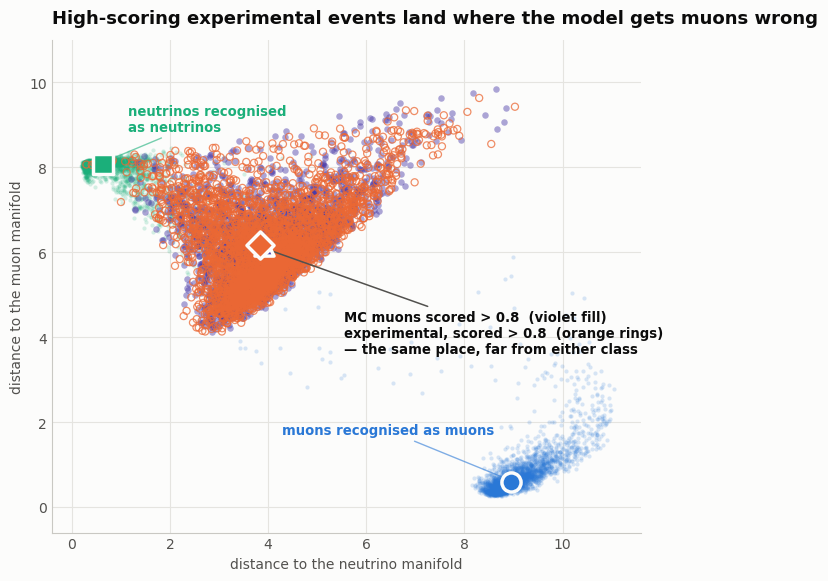

In [9]:
# Figure 1 — the identification.
def sample(sql, n):
    """A sample that does not change between runs.

    Ordering by a hash of the event key rather than sampling: a reservoir sample depends on
    the order the parallel scan happens to return rows in, so it differs run to run even with
    a seed, and pulling 23M rows into pandas to keep 3,000 was wasteful besides. The hash is
    unbiased with respect to anything in the data.
    """
    return query(f"SELECT x, y FROM ({sql}) ORDER BY hash(event_fk) LIMIT {n}")

xy = "p.event_fk, d.distance_to_nu AS x, d.distance_to_mu AS y"
mc_from = ("FROM predictions p JOIN splits s USING(event_fk) "
           "JOIN distances d USING(event_fk) WHERE ")
ordinary  = sample(f"SELECT {xy} {mc_from} {MUONS} AND NOT {HIGH}", 3000)
neutrinos = sample(f"SELECT {xy} {mc_from} {NEUTRINOS} AND {HIGH}", 3000)
misread   = sample(f"SELECT {xy} {mc_from} {MUONS} AND {HIGH}", 2500)
# not sampled (3,044 rows), but ordered all the same: overlapping points are drawn in row
# order, so an unstable order changes the rendered image
exp_high  = query(f"""SELECT x, y FROM (SELECT {xy} FROM exp.predictions p
    JOIN exp.splits s USING(event_fk) JOIN exp.distances d USING(event_fk)
    WHERE {EXP_SEL} AND {HIGH}) ORDER BY hash(event_fk)""")

fig, ax = plt.subplots(figsize=(7.6, 6.4)); fig.patch.set_facecolor(SURFACE); style(ax)
ax.scatter(ordinary.x, ordinary.y, s=9, c=BLUE, alpha=0.18, linewidths=0, zorder=1)
ax.scatter(neutrinos.x, neutrinos.y, s=9, c=AQUA, alpha=0.18, linewidths=0, zorder=1)
ax.scatter(misread.x, misread.y, s=22, c=VIOLET, alpha=0.45, linewidths=0, zorder=2)
ax.scatter(exp_high.x, exp_high.y, s=26, facecolors="none", edgecolors=ORANGE,
           linewidths=0.9, alpha=0.75, zorder=3)
for frame, colour, marker in [(ordinary, BLUE, "o"), (neutrinos, AQUA, "s"),
                              (misread, VIOLET, "^"), (exp_high, ORANGE, "D")]:
    ax.scatter(frame.x.median(), frame.y.median(), s=190, marker=marker, c=colour,
               edgecolors=SURFACE, linewidths=2.5, zorder=6)
ax.set_xlim(-0.4, 11.6); ax.set_ylim(-0.6, 11.0)
ax.set_xlabel("distance to the neutrino manifold", color=MUTED)
ax.set_ylabel("distance to the muon manifold", color=MUTED)
ax.set_title("High-scoring experimental events land where the model gets muons wrong",
             loc="left", fontsize=13, fontweight="bold", color=INK, pad=12)
ax.annotate("muons recognised as muons", (9.0, 0.6), textcoords="offset points",
            xytext=(-14, 34), ha="right", color=BLUE, fontsize=9.5, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=BLUE, linewidth=1, alpha=0.6))
ax.annotate("neutrinos recognised\nas neutrinos", (0.4, 8.0), textcoords="offset points",
            xytext=(26, 26), color=AQUA, fontsize=9.5, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=AQUA, linewidth=1, alpha=0.6))
ax.annotate("MC muons scored > 0.8  (violet fill)\n"
            "experimental, scored > 0.8  (orange rings)\n"
            "— the same place, far from either class", (3.9, 6.1),
            textcoords="offset points", xytext=(58, -76), color=INK, fontsize=9.5,
            fontweight="bold", arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=1.1))
plt.savefig("figures/identification.png", dpi=160, bbox_inches="tight", facecolor=SURFACE)
plt.show()

**Figure 1.** Each dot is one event, positioned by how far it sits from the neutrino and the
muon reference manifolds; large markers are the population medians. Ordinary muons (blue) sit
on the muon manifold, genuine neutrinos (green) on the neutrino one. Both high-scoring
populations sit on neither, six times further from their own class than an ordinary event, and
the experimental one (orange rings) lands on top of the misread simulated muons (violet fill).

Read it as §1.4 requires. The orange rings are all 3,044 experimental events above the
threshold, roughly half of them the predicted muon background; the surplus half cannot be drawn
on its own. What the figure establishes is that the mixture has **no second component** — no
displacement, no second lobe, no broadening beyond the misread muons anywhere in the plane.
Since the surplus is about half the plotted population, any second kind of event would have to
be distributed almost indistinguishably from misread muons to leave the picture unchanged.

> **Verdict.** That the high-scoring experimental population *is* the classifier's failure
> mode reproduced on real data: `verified`. That the **surplus** is too: `consistent`, resting
> on the absence of a second component rather than on observing the surplus directly — a
> strong constraint at 50% mixture weight, but not the same thing as a direct measurement.
>
> *What would overturn it:* a population that matches the misread muons this closely while
> differing in origin. None of the four populations examined does. §8 records the one subset
> that does not fit this account.

## 4. Is it the detector?

One real fault was found, and it is small.

In [10]:
# The fault is a property of four channels, not of the runs as a whole, so the comparison has
# to be made event by event. `bad_channel_events.parquet` lists the (run, index) pairs whose
# hits touch channels 222/224/225/227; it is written by the data-quality scan documented in
# DATA_QUALITY.md.
touched = pd.read_parquet("bad_channel_events.parquet")
db.register("touched", touched)

display(query(f"""
    SELECT CASE WHEN t.part_key IS NOT NULL THEN 'events touching a faulty channel'
                WHEN s.excluded THEN 'the rest of those two runs'
                ELSE 'the other 27 runs' END AS sample,
           count(*) AS quality_events,
           count(*) FILTER (WHERE {HIGH}) AS high_score,
           round(100.0 * count(*) FILTER (WHERE {HIGH}) / count(*), 4) AS rate_percent,
           round(median(sc.q_total), 1) AS median_q_total
    FROM exp.predictions p JOIN exp.splits s USING (event_fk)
    JOIN exp.scalars sc USING (event_fk)
    LEFT JOIN touched t ON t.part_key = s.part_key AND t.local_idx = s.local_idx
    WHERE {QUALITY} GROUP BY 1 ORDER BY 3 DESC
"""))
print("The two runs as a whole look almost normal (0.10% against 0.096%) — the fault is "
      "concentrated\nin the 5,304 events that actually touch those channels, where the rate "
      "is 8.7 times higher\nand the median charge is 2.4 times larger.\n\n"
      "Whole runs are excluded rather than those 5,304 events, which costs 168,000 good "
      "events.\nFour channels on one string behaving that way is a symptom; keeping the rest "
      "of a run\nassumes the remainder is healthy, and nothing tested establishes that.")

,sample,quality_events,high_score,rate_percent,median_q_total
0,the other 27 runs,3180681,3044,0.0957,56.7
1,the rest of those two runs,167731,138,0.0823,54.1
2,events touching a faulty channel,5304,38,0.7164,129.7


The two runs as a whole look almost normal (0.10% against 0.096%) — the fault is concentrated
in the 5,304 events that actually touch those channels, where the rate is 8.7 times higher
and the median charge is 2.4 times larger.

Whole runs are excluded rather than those 5,304 events, which costs 168,000 good events.
Four channels on one string behaving that way is a symptom; keeping the rest of a run
assumes the remainder is healthy, and nothing tested establishes that.


Four channels on one string of cluster 2 emit charges up to 3,169.8 p.e. against a median hit
of 0.97. No charge limit exists anywhere before the classifier — the sig-noise network
receives such a hit as 863 standard deviations and calls it signal every time — so the event
gains hits it should not have and passes the quality cut. Events touching those channels score
above 0.8 **8.7 times** more often. They fire in exactly two runs, excluded throughout.
Removing those two runs changes the excess by about 1%.

Everything else tested came back negative:

| tested | outcome |
|---|---|
| bioluminescence bursts | `refuted` — intervals between high-score events are Poisson: 0.099% shorter than 0.1% of the mean against 0.100% expected |
| the inherited cluster 1 and 4 exclusion | `refuted` — channel 71 in cluster 4 is normal by occupancy (0.889 of the cluster median) and by mean charge (1.019); cluster 4 has no anomalous channel at all |
| per-cluster trigger thresholds | no difference — 1st percentile of charge spans 0.122–0.201 across clusters, correlation with the high-score rate +0.28 |
| isolated causally-impossible hits | present but small — 5 of 3,044 experimental high-score events and 6 of 7,751 simulated ones, so it largely cancels |
| string motion | real but unquantified — one channel moves 2.3 m between runs; within a 22-hour run a single position is used |

Out of reach with what we hold: DAQ dead time and buffer overflows, water optical properties,
calibration provenance, event splitting at readout boundaries. These need detector monitoring
data. Full record in `DATA_QUALITY.md`.

> **Verdict — `verified`.** A detector fault exists, is understood, and accounts for about 1%
> of the high-score sample. It does not explain the excess.
>
> *What would overturn it:* a defect in the untested list above that concentrates in the
> high-score sample. None of the five tested does.

## 5. What the simulation gets wrong

§3 identified the events as muon-like. The simulation produces such events too — just too few.
The question is what distinguishes the ones it produces.

First, which muons the classifier misreads, taken straight from Monte Carlo truth rather than
from any proxy:

In [11]:
display(query(f"""
    SELECT 'all quality muons' AS sample, count(*) AS events,
           round(median(t.zenith_deg), 1) AS zenith_deg,
           round(quantile_cont(t.zenith_deg, 0.25), 1) AS zenith_q25,
           round(quantile_cont(t.zenith_deg, 0.75), 1) AS zenith_q75,
           round(median(t.primary_energy_gev), 0) AS energy_gev
    FROM predictions p JOIN splits s USING(event_fk) JOIN truth t USING(event_fk)
    WHERE {MUONS}
    UNION ALL
    SELECT 'muons scored > 0.8', count(*), round(median(t.zenith_deg), 1),
           round(quantile_cont(t.zenith_deg, 0.25), 1),
           round(quantile_cont(t.zenith_deg, 0.75), 1),
           round(median(t.primary_energy_gev), 0)
    FROM predictions p JOIN splits s USING(event_fk) JOIN truth t USING(event_fk)
    WHERE {MUONS} AND {HIGH}
"""))
print("Zenith convention: 90 deg is the horizon, 180 deg is straight down. The simulation "
      "generates\nmuons only above 90 and neutrinos only below it.")

,sample,events,zenith_deg,zenith_q25,zenith_q75,energy_gev
0,all quality muons,23167718,136.3,125.3,147.7,557.0
1,muons scored > 0.8,7751,106.8,102.7,112.2,372.0


Zenith convention: 90 deg is the horizon, 180 deg is straight down. The simulation generates
muons only above 90 and neutrinos only below it.


In [12]:
display(query(f"""
    SELECT CASE WHEN t.zenith_deg < 95 THEN '90-95'   WHEN t.zenith_deg < 100 THEN '95-100'
                WHEN t.zenith_deg < 105 THEN '100-105' WHEN t.zenith_deg < 110 THEN '105-110'
                WHEN t.zenith_deg < 120 THEN '110-120' WHEN t.zenith_deg < 140 THEN '120-140'
                ELSE '140-180' END AS zenith_band,
           count(*) AS events, count(*) FILTER (WHERE {HIGH}) AS misread,
           round(100.0 * count(*) FILTER (WHERE {HIGH}) / count(*), 4) AS misread_percent
    FROM predictions p JOIN splits s USING(event_fk) JOIN truth t USING(event_fk)
    WHERE {MUONS} GROUP BY 1 ORDER BY min(t.zenith_deg)
"""))

,zenith_band,events,misread,misread_percent
0,90-95,43,8,18.6047
1,95-100,16326,854,5.2309
2,100-105,151534,2201,1.4525
3,105-110,506759,2036,0.4018
4,110-120,2776116,1983,0.0714
5,120-140,10104345,593,0.0059
6,140-180,9612595,76,0.0008


A muon within 5° of the horizon is called a neutrino **18.6%** of the time; one from straight
above, 0.0008% — a factor of 23,000. The misread muons are therefore a narrow, uniform
population: median true zenith 107° with quartiles 102–112°.

This is the whole mechanism. The simulation contains no down-going neutrinos and no up-going
muons, so during training "neutrino" and "up-going" were the same statement, and the network
placed its boundary on the horizon.

Now the same events against data. Charge is expressed **per signal hit**, so a difference in
how many modules an event lights cannot masquerade as a difference in how much light it
carries:

In [13]:
# Charge per hit removes the dependence on multiplicity by construction, so the full
# high-score sample can be used rather than a thin exactly-matched subset.
display(query(f"""
    SELECT 'MC muons' AS sample, count(*) AS events,
           median(sc.n_sig_hits) AS hits, median(sc.n_channels) AS channels,
           round(median(sc.q_mean), 2) AS charge_per_hit,
           round(quantile_cont(sc.q_mean, 0.25), 2) AS q25,
           round(quantile_cont(sc.q_mean, 0.75), 2) AS q75,
           round(median(sc.q_max), 1) AS q_max
    FROM predictions p JOIN splits s USING(event_fk) JOIN scalars sc USING(event_fk)
    WHERE {MUONS} AND {HIGH}
    UNION ALL
    SELECT 'experimental', count(*), median(sc.n_sig_hits), median(sc.n_channels),
           round(median(sc.q_mean), 2), round(quantile_cont(sc.q_mean, 0.25), 2),
           round(quantile_cont(sc.q_mean, 0.75), 2), round(median(sc.q_max), 1)
    FROM exp.predictions p JOIN exp.splits s USING(event_fk)
    JOIN exp.scalars sc USING(event_fk) WHERE {EXP_SEL} AND {HIGH}
"""))
print("Hit and module counts agree to within one hit, and charge is expressed per "
      "hit anyway,\nso multiplicity cannot account for the difference in what each "
      "hit carries.")

,sample,events,hits,channels,charge_per_hit,q25,q75,q_max
0,MC muons,7751,10.0,10.0,4.69,3.08,8.58,18.8
1,experimental,3044,11.0,10.0,6.39,3.76,12.39,30.9


Hit and module counts agree to within one hit, and charge is expressed per hit anyway,
so multiplicity cannot account for the difference in what each hit carries.


In [14]:
# Is the light deficit specific to the events the classifier picks, or does it run through the
# whole sample? And could one cause — too little light — also produce the composition
# difference of section 2, by pushing marginal hits below the signal threshold?
display(query(f"""
    SELECT 'MC muons, all quality events' AS sample, count(*) AS events,
           median(sc.n_sig_hits) AS hits, round(median(sc.q_mean), 2) AS charge_per_hit
    FROM predictions p JOIN splits s USING(event_fk) JOIN scalars sc USING(event_fk)
    WHERE {MUONS}
    UNION ALL
    SELECT 'experimental, all quality events', count(*), median(sc.n_sig_hits),
           round(median(sc.q_mean), 2)
    FROM exp.predictions p JOIN exp.splits s USING(event_fk)
    JOIN exp.scalars sc USING(event_fk) WHERE {EXP_SEL}
    UNION ALL
    SELECT 'MC muons, score > 0.8', count(*), median(sc.n_sig_hits), round(median(sc.q_mean), 2)
    FROM predictions p JOIN splits s USING(event_fk) JOIN scalars sc USING(event_fk)
    WHERE {MUONS} AND {HIGH}
    UNION ALL
    SELECT 'experimental, score > 0.8', count(*), median(sc.n_sig_hits),
           round(median(sc.q_mean), 2)
    FROM exp.predictions p JOIN exp.splits s USING(event_fk)
    JOIN exp.scalars sc USING(event_fk) WHERE {EXP_SEL} AND {HIGH}
"""))
print("The deficit is present across the whole quality sample — 3.58 against 4.02 p.e. per "
      "hit, 12% —\nand three times larger in the events the classifier scores high, 4.69 "
      "against 6.39, 36%.\n\n"
      "The tempting single explanation does not survive: if the simulation were simply too "
      "faint, its\nevents would lose marginal hits and carry fewer of them. They do not — "
      "both samples sit at 13\nhits. So the composition difference of section 2 and the light "
      "deficit are not obviously the\nsame effect, and this notebook does not establish a "
      "common cause.")

,sample,events,hits,charge_per_hit
0,"MC muons, all quality events",23167718,13.0,3.58
1,"experimental, all quality events",3180681,13.0,4.02
2,"MC muons, score > 0.8",7751,10.0,4.69
3,"experimental, score > 0.8",3044,11.0,6.39


The deficit is present across the whole quality sample — 3.58 against 4.02 p.e. per hit, 12% —
and three times larger in the events the classifier scores high, 4.69 against 6.39, 36%.

The tempting single explanation does not survive: if the simulation were simply too faint, its
events would lose marginal hits and carry fewer of them. They do not — both samples sit at 13
hits. So the composition difference of section 2 and the light deficit are not obviously the
same effect, and this notebook does not establish a common cause.


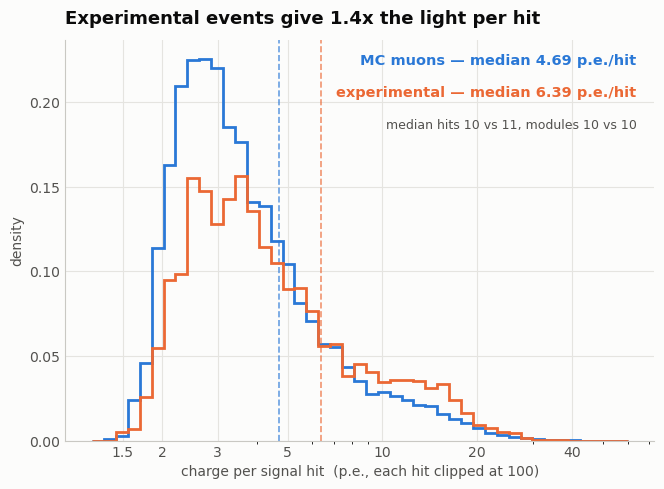

MC muons 7,751 events, experimental 3,044; dashed lines mark the medians.


In [15]:
# Figure 2 — the same events, in charge per hit.
mc_charge = query(f"""SELECT sc.q_mean AS q, sc.n_sig_hits AS hits, sc.n_channels AS modules
    FROM predictions p JOIN splits s USING(event_fk)
    JOIN scalars sc USING(event_fk) WHERE {MUONS} AND {HIGH}""")
exp_charge = query(f"""SELECT sc.q_mean AS q, sc.n_sig_hits AS hits, sc.n_channels AS modules
    FROM exp.predictions p
    JOIN exp.splits s USING(event_fk) JOIN exp.scalars sc USING(event_fk)
    WHERE {EXP_SEL} AND {HIGH}""")

fig, ax = plt.subplots(figsize=(7.6, 5.2)); fig.patch.set_facecolor(SURFACE); style(ax)
edges = np.logspace(np.log10(1.2), np.log10(60), 46)
for frame, colour in [(mc_charge, BLUE), (exp_charge, ORANGE)]:
    ax.hist(frame.q, bins=edges, density=True, histtype="step", linewidth=2, color=colour)
    ax.axvline(frame.q.median(), color=colour, linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(0.97, 0.94, f"MC muons — median {mc_charge.q.median():.2f} p.e./hit",
        transform=ax.transAxes, ha="right", color=BLUE, fontsize=10.5, fontweight="bold")
ax.text(0.97, 0.86, f"experimental — median {exp_charge.q.median():.2f} p.e./hit",
        transform=ax.transAxes, ha="right", color=ORANGE, fontsize=10.5, fontweight="bold")
# stated rather than implied: charge per hit already divides by hit count, but the two
# samples are not identical in size, so the medians are put on the figure
ax.text(0.97, 0.78, f"median hits {mc_charge.hits.median():.0f} vs "
        f"{exp_charge.hits.median():.0f}, modules {mc_charge.modules.median():.0f} vs "
        f"{exp_charge.modules.median():.0f}", transform=ax.transAxes, ha="right",
        color=MUTED, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("charge per signal hit  (p.e., each hit clipped at 100)", color=MUTED)
ax.set_ylabel("density", color=MUTED)
ax.set_title(f"Experimental events give "
             f"{exp_charge.q.median() / mc_charge.q.median():.1f}x the light per hit",
             loc="left", fontsize=13,
             fontweight="bold", color=INK, pad=12)
ax.set_xticks([1.5, 2, 3, 5, 10, 20, 40])
ax.set_xticklabels(["1.5", "2", "3", "5", "10", "20", "40"])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
plt.savefig("figures/light_yield.png", dpi=160, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"MC muons {len(mc_charge):,} events, experimental {len(exp_charge):,}; "
      f"dashed lines mark the medians.")

**Figure 2.** All high-scoring events, with charge expressed per signal hit, so the number of
hits cannot drive the difference: the quantity divides by it. The two samples are close but
not identical in size — median 10 hits against 11, 10 modules against 10, printed on the figure
— and the shift in light per hit, 1.4x, is far larger than that 10% difference in multiplicity
could produce.

The experimental distribution is shifted bodily towards more light rather than growing a tail:
the simulation makes events of about the right size and shape and makes them too faint. This
is §5's light deficit measured directly, and figure 4 shows the same thing resolved in two
dimensions.

In [16]:
def excess_by(variable, edges, label):
    rows = []
    for low, high in zip(edges[:-1], edges[1:]):
        band = f"sc.{variable} >= {low} AND sc.{variable} < {high}"
        mc = query(f"""SELECT count(*) n, count(*) FILTER (WHERE {HIGH}) k
            FROM predictions p JOIN splits s USING(event_fk) JOIN scalars sc USING(event_fk)
            WHERE {MUONS} AND {band}""").iloc[0]
        ex = query(f"""SELECT count(*) n, count(*) FILTER (WHERE {HIGH}) k
            FROM exp.predictions p JOIN exp.splits s USING(event_fk)
            JOIN exp.scalars sc USING(event_fk) WHERE {EXP_SEL} AND {band}""").iloc[0]
        if mc.k == 0 or ex.n == 0:
            continue
        predicted = ex.n * mc.k / mc.n
        rows.append(dict(variable=label, band=f"{low}-{high}", observed=int(ex.k),
                         predicted=round(predicted, 1), excess=round(ex.k - predicted, 1),
                         ratio=round(ex.k / predicted, 2)))
    return pd.DataFrame(rows)

robustness = pd.concat([
    excess_by("r_vert",     [0, 0.4, 0.6, 0.8, 1.2, 99],   "r_vert (shape)"),
    excess_by("q_total",    [0, 30, 60, 120, 100000],      "q_total (light)"),
    excess_by("n_sig_hits", [8, 10, 12, 16, 1000],         "n_sig_hits"),
], ignore_index=True)
display(robustness)
print(f"total excess, summed over any one binning: "
      f"{robustness[robustness.variable == 'r_vert (shape)'].excess.sum():.0f} events")

,variable,band,observed,predicted,excess,ratio
0,r_vert (shape),0-0.4,464,436.5,27.5,1.06
1,r_vert (shape),0.4-0.6,1291,632.3,658.7,2.04
2,r_vert (shape),0.6-0.8,987,353.6,633.4,2.79
3,r_vert (shape),0.8-1.2,281,120.0,161.0,2.34
4,r_vert (shape),1.2-99,21,3.5,17.5,6.07
5,q_total (light),0-30,371,158.7,212.3,2.34
6,q_total (light),30-60,905,355.9,549.1,2.54
7,q_total (light),60-120,775,293.3,481.7,2.64
8,q_total (light),120-100000,993,269.7,723.3,3.68
9,n_sig_hits,8-10,1016,369.3,646.7,2.75


total excess, summed over any one binning: 1498 events


The excess is present in every band of every variable, so no conclusion here rests on the
choice. What the slicings do differ in is *where* it concentrates, and that difference is the
subject of §6.

> **Verdict — `consistent`.** The simulation under-produces light: by 12% across the whole
> quality sample and by 36% in the events the classifier scores high. It gets hit multiplicity
> right — both samples sit at 13 hits — and gets the shape composition wrong in a separate way
> (§2). Whether the light deficit comes from the energy spectrum at grazing angles, bundle
> multiplicity, or the light propagation model, these data cannot separate, and they do not
> establish that the light deficit and the composition difference share a cause.
>
> *What would overturn it:* showing the charge difference is a calibration offset in the data
> rather than a deficit in the simulation. Charge calibration provenance is not available to
> us (§4), so this remains the main alternative and it is not excluded.

### Where the excess sits, in quantities the network never sees

The two axes are measured from the hits alone: **track-likeness** is the squared correlation
of hit time with depth — 1 means the hits lie on a line, as light swept along a track gives —
and **charge per hit** is the event's total charge divided by its number of signal hits, so
event size cannot masquerade as brightness. Neither uses the classifier.

Reading the panels: ordinary muons and atmospheric neutrinos both pile up at high
track-likeness, which is what a through-going track looks like. Applying the score cut moves
the muon and the experimental panels to the bottom-left corner — dim of track structure,
brighter per hit — while the neutrino panels barely move, because the classifier is selecting
almost all of them anyway.

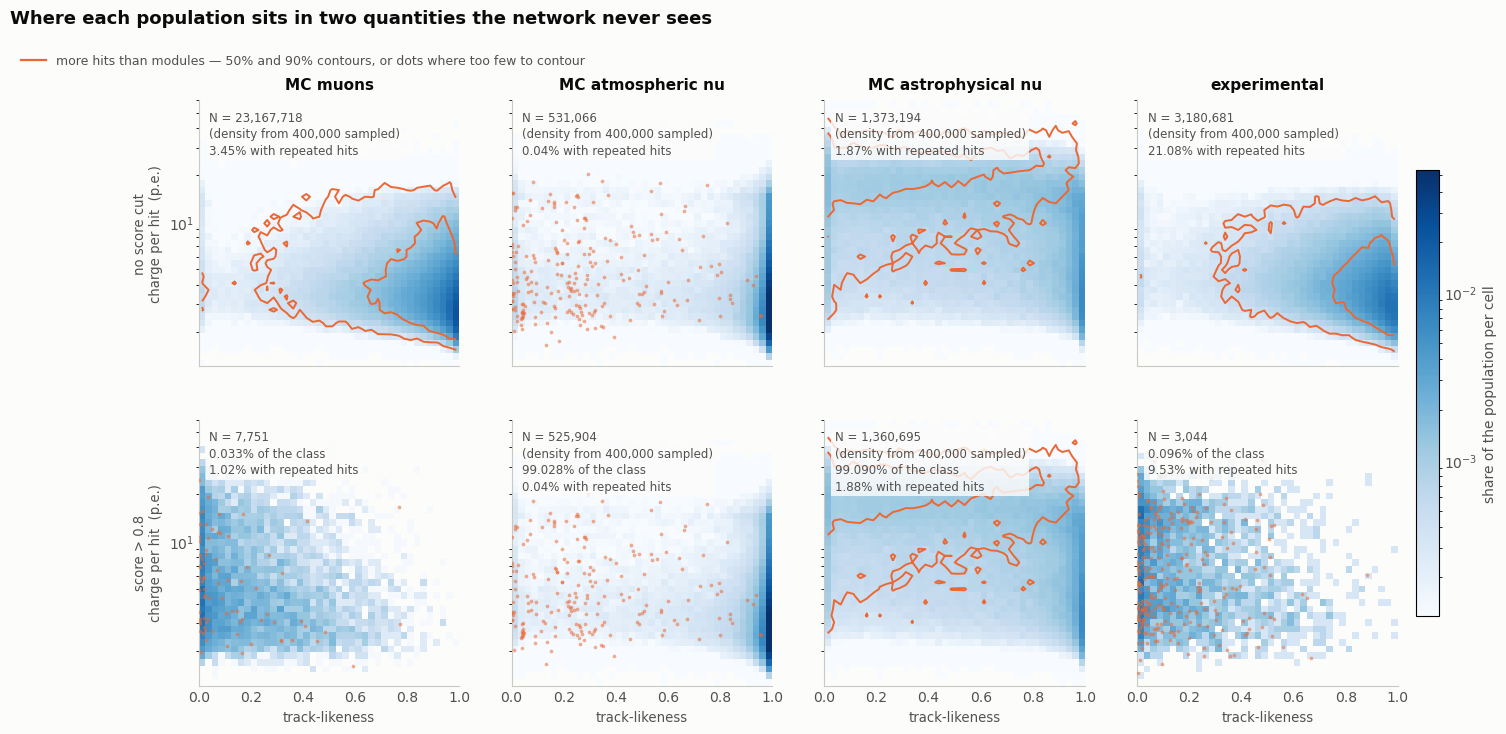

In [17]:
# Figure 3 — where each population lives in two objective quantities. No network output is
# used for the axes: track-likeness is the r^2 of hit time against depth, charge per hit is
# the summed charge divided by the number of signal hits.
from matplotlib.colors import LogNorm

REPEATED = "sc.n_sig_hits::DOUBLE / sc.n_channels > 1.2"

def plane(prefix, klass, score_cut, *, repeated_only=False, limit=400_000):
    where = ((f"{MC_SEL} AND s.data_class = '{klass}'") if prefix == "" else EXP_SEL)
    if score_cut:
        where += f" AND {HIGH}"
    if repeated_only:
        where += f" AND {REPEATED}"
    # the sample is drawn from the filtered result, not from the table: placing USING SAMPLE
    # at the outer level would thin the selection instead of the source
    return query(f"""
        SELECT track_likeness, charge_per_hit FROM (
            SELECT p.event_fk, d.fit_quality AS track_likeness, sc.q_mean AS charge_per_hit
            FROM {prefix}predictions p JOIN {prefix}splits s USING (event_fk)
            JOIN {prefix}scalars sc USING (event_fk) JOIN {prefix}direction d USING (event_fk)
            WHERE {where} AND d.fit_quality IS NOT NULL
        ) ORDER BY hash(event_fk) LIMIT {limit}""")

POPULATIONS = [("MC muons", "", "muatm_2020"), ("MC atmospheric nu", "", "nuatm_2020"),
               ("MC astrophysical nu", "", "nue2_2020"), ("experimental", "exp.", None)]

def population_size(prefix, klass, score_cut, *, repeated_only=False):
    """True number of events, which is not the number the density was estimated from."""
    where = ((f"{MC_SEL} AND s.data_class = '{klass}'") if prefix == "" else EXP_SEL)
    if score_cut:
        where += f" AND {HIGH}"
    if repeated_only:
        where += f" AND {REPEATED}"
    return int(query(f"""
        SELECT count(*) AS n FROM {prefix}predictions p
        JOIN {prefix}splits s USING (event_fk) JOIN {prefix}scalars sc USING (event_fk)
        JOIN {prefix}direction d USING (event_fk)
        WHERE {where} AND d.fit_quality IS NOT NULL""").n.iloc[0])

X_EDGES = np.linspace(0, 1, 41)
Y_EDGES = np.logspace(np.log10(1.2), np.log10(60), 41)

# All eight histograms first, so one colour scale can serve them all — normalising each panel
# to its own range is what made every panel look alike.
panels = {}
for row, score_cut in enumerate([False, True]):
    for col, (label, prefix, klass) in enumerate(POPULATIONS):
        frame = plane(prefix, klass, score_cut)
        counts, _, _ = np.histogram2d(frame.track_likeness, frame.charge_per_hit,
                                      bins=[X_EDGES, Y_EDGES])
        panels[(row, col)] = (counts / counts.sum(), len(frame))
filled = np.concatenate([d[d > 0].ravel() for d, _ in panels.values()])
VMIN, VMAX = np.percentile(filled, 25), np.percentile(filled, 99.9)

fig, axes = plt.subplots(2, 4, figsize=(16.0, 7.6), sharex=True, sharey=True)
fig.patch.set_facecolor(SURFACE)
for row, score_cut in enumerate([False, True]):
    for col, (label, prefix, klass) in enumerate(POPULATIONS):
        ax = axes[row, col]; style(ax); ax.grid(False)
        density, n_sampled = panels[(row, col)]
        mesh = ax.pcolormesh(X_EDGES, Y_EDGES, density.T, cmap="Blues",
                             norm=LogNorm(vmin=VMIN, vmax=VMAX), shading="flat")
        ax.set_yscale("log")

        # Events with more hits than modules, as a light second layer. Contoured where there
        # are enough of them to have a shape, dotted where there are not — a contour drawn
        # through 79 events would invent structure.
        n_repeated = population_size(prefix, klass, score_cut, repeated_only=True)
        repeated = plane(prefix, klass, score_cut, repeated_only=True, limit=40_000)
        if n_repeated >= 500 and len(repeated) >= 500:
            counts, _, _ = np.histogram2d(repeated.track_likeness, repeated.charge_per_hit,
                                          bins=[X_EDGES, Y_EDGES])
            share = counts / counts.sum()
            ordered = np.sort(share.ravel())[::-1]
            cumulative = np.cumsum(ordered)
            levels = [ordered[np.searchsorted(cumulative, f)] for f in (0.5, 0.9)][::-1]
            ax.contour(0.5 * (X_EDGES[:-1] + X_EDGES[1:]),
                       0.5 * (Y_EDGES[:-1] + Y_EDGES[1:]), share.T,
                       levels=levels, colors=ORANGE, linewidths=1.4, zorder=4)
        elif len(repeated):
            ax.scatter(repeated.track_likeness, repeated.charge_per_hit, s=7, c=ORANGE,
                       alpha=0.55, linewidths=0, zorder=4)

        total = population_size(prefix, klass, score_cut)
        note = f"N = {total:,}"
        if n_sampled < total:
            note += f"\n(density from {n_sampled:,} sampled)"
        if score_cut:
            note += f"\n{100 * total / population_size(prefix, klass, False):.3f}% of the class"
        # two decimals: atmospheric nu is 0.04%, and "0.0%" would read as "none" against the
        # 235 events the caption quotes
        note += f"\n{100 * n_repeated / total:.2f}% with repeated hits"
        ax.text(0.04, 0.96, note, transform=ax.transAxes, va="top", fontsize=8.5,
                color=MUTED, linespacing=1.35, zorder=6,
                bbox=dict(facecolor=SURFACE, edgecolor="none", alpha=0.82, pad=2.5))

        if row == 0:
            ax.set_title(label, fontsize=11, fontweight="bold", color=INK, pad=8)
        if col == 0:
            ax.set_ylabel(("no score cut" if not score_cut else "score > 0.8")
                          + "\ncharge per hit  (p.e.)", color=MUTED, fontsize=9.5)
        if row == 1:
            ax.set_xlabel("track-likeness", color=MUTED, fontsize=9.5)

from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([], [], color=ORANGE, linewidth=1.6,
                           label="more hits than modules — 50% and 90% contours, "
                                 "or dots where too few to contour")],
           loc="upper left", bbox_to_anchor=(0.007, 0.955), frameon=False,
           fontsize=9, labelcolor=MUTED)
bar = fig.colorbar(mesh, ax=axes, fraction=0.018, pad=0.015)
bar.set_label("share of the population per cell", color=MUTED)
bar.ax.tick_params(colors=MUTED, length=0)
fig.suptitle("Where each population sits in two quantities the network never sees",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=INK, y=1.0)
plt.savefig("figures/populations_plane.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

**Figure 3.** Each panel is one population in the same two objective quantities:
track-likeness across, charge per hit up. Neither axis uses any network output. All eight
panels share the same bins **and the same colour scale**, so a darker cell means a genuinely
larger share of that population and the panels can be compared by colour, not only by shape.

**Read the panel labels, not the picture, for rates.** `N` is the true number of events in that
population; where the density had to be estimated from a sample the panel says so, and the
bottom row gives the fraction of the class surviving the cut. Colour is the share *within* a
population, so it carries no information about how large the populations are relative to one
another — that comparison is 0.0335% of simulated muons against 0.0957% of experimental
events, a factor 2.9 before the shape correction of §2.

**The orange layer** marks events with more hits than modules, drawn as 50% and 90% contours
where that subset is large enough to have a shape and as individual dots where it is not
(atmospheric ν has 235 such events in 531,066). It is a separate discrepancy from the excess,
taken up two cells below.

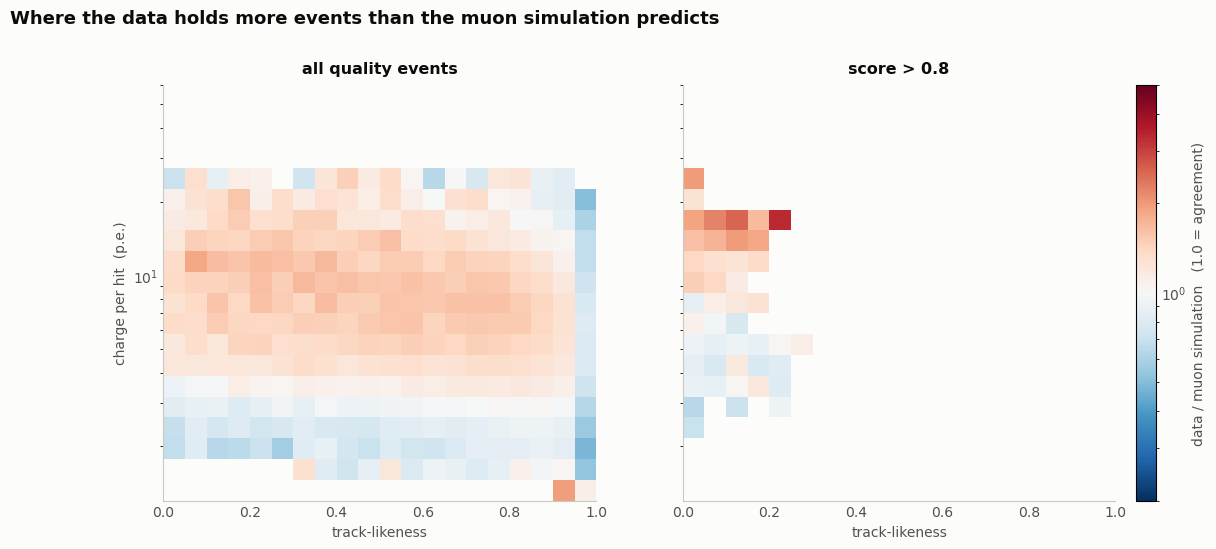

Cells holding fewer than 20 events in either sample are left blank.


In [18]:
# Figure 4 — the excess itself: how much more often the data occupies each cell than the muon
# simulation does. Both densities are normalised to their own totals, so this is relative
# over- and under-representation, and 1.0 means the two agree.
from matplotlib.colors import LogNorm

# A coarser grid than figure 3: the score-cut panel holds 3,044 events against 7,751, so 1,600
# cells would leave most of them empty and the rest dominated by Poisson noise.
X_COARSE = np.linspace(0, 1, 21)
Y_COARSE = np.logspace(np.log10(1.2), np.log10(60), 21)

def density(prefix, klass, score_cut, limit=800_000):
    frame = plane(prefix, klass, score_cut, limit=limit)
    counts, _, _ = np.histogram2d(frame.track_likeness, frame.charge_per_hit,
                                  bins=[X_COARSE, Y_COARSE])
    return counts / counts.sum(), counts

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4), sharex=True, sharey=True)
fig.patch.set_facecolor(SURFACE)
for ax, score_cut, title in zip(axes, [False, True],
                                ["all quality events", "score > 0.8"]):
    muon_density, muon_counts = density("", "muatm_2020", score_cut)
    exp_density, exp_counts = density("exp.", None, score_cut)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where((muon_counts >= 20) & (exp_counts >= 20),
                         exp_density / muon_density, np.nan)
    style(ax); ax.grid(False)
    mesh = ax.pcolormesh(X_COARSE, Y_COARSE, ratio.T, cmap="RdBu_r",
                         norm=LogNorm(vmin=0.2, vmax=5.0), shading="flat")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=11.5, fontweight="bold", color=INK, pad=8)
    ax.set_xlabel("track-likeness", color=MUTED)
axes[0].set_ylabel("charge per hit  (p.e.)", color=MUTED)
bar = fig.colorbar(mesh, ax=axes, fraction=0.035, pad=0.02)
bar.set_label("data / muon simulation   (1.0 = agreement)", color=MUTED)
bar.ax.tick_params(colors=MUTED, length=0)
fig.suptitle("Where the data holds more events than the muon simulation predicts",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=INK, y=1.02)
plt.savefig("figures/excess_map.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print("Cells holding fewer than 20 events in either sample are left blank.")

**Figure 4.** The same plane as figure 3, now as the ratio of the two densities. Red marks
cells the data occupies more often than the muon simulation predicts, blue less often; each
density is normalised to its own total, so this measures *relative* occupancy rather than
absolute rates. Cells with fewer than 20 events in either sample are blank, and the grid is
coarser than figure 3 because the score-cut panel holds only 3,044 events.

**Left, before the classifier is consulted at all**, the disagreement is already there and it
is structured horizontally: red between roughly 4 and 20 p.e. per hit and blue below 3, fading
back to agreement above 20. This holds in every track-likeness column, not just in the
marginal — measured in fifths of the axis, the data's share below 3 p.e. runs 0.65–0.79 of the
simulation's and its share between 4 and 20 p.e. runs 1.16–1.21. The simulation puts too many events in the dim rows and too few in the
bright ones. The blue column at track-likeness near 1 is the same statement from the other
side — the data has proportionally fewer perfectly track-like events. This is §5's light
deficit, drawn without using the network.

**Right, after the cut**, the surviving events sit in a narrow strip of low track-likeness, and
within it the data runs densest in a band around 10–20 p.e. per hit.

Two things follow, and both matter for how the excess can be selected. It is **not a compact
island** in this plane — it is a broad shift along the charge axis, which is exactly why the
physical cuts of §5 capture it only weakly. And its location has nothing to do with the
neutrino populations of figure 3, which occupy the opposite end of the track-likeness axis.

### A second discrepancy: more hits than modules

The orange layer of figure 3 is the largest data/simulation disagreement anywhere in this
notebook, and it is not the excess. Since it would otherwise sit unexplained on the figure,
it is settled here.

An optical module can register more than one hit in the same event — from scattered light, a
late photon, or an instrumental after-pulse. The ratio `n_sig_hits / n_channels` counts that
directly: 1.0 means every hit landed on a different module, above 1.2 means a fifth or more of
the hits are repeats. The table below gives, for each population, how often this happens and
what those events look like in the two quantities of figure 3.

In [19]:
HITS_PER_MODULE = "sc.n_sig_hits::DOUBLE / sc.n_channels"
REPEATED = f"{HITS_PER_MODULE} > 1.2"

def repeated_profile(label, prefix, klass):
    where = (f"{MC_SEL} AND s.data_class = '{klass}'") if prefix == "" else EXP_SEL
    return query(f"""
        SELECT '{label}' AS population,
               count(*) AS quality_events,
               count(*) FILTER (WHERE {REPEATED}) AS repeated,
               100.0 * count(*) FILTER (WHERE {REPEATED}) / count(*) AS pct_repeated,
               median(sc.q_mean) FILTER (WHERE {REPEATED})      AS q_per_hit_repeated,
               median(sc.q_mean) FILTER (WHERE NOT {REPEATED})  AS q_per_hit_rest,
               median(d.fit_quality) FILTER (WHERE {REPEATED})     AS tracklike_repeated,
               median(d.fit_quality) FILTER (WHERE NOT {REPEATED}) AS tracklike_rest
        FROM {prefix}predictions p JOIN {prefix}splits s USING (event_fk)
        JOIN {prefix}scalars sc USING (event_fk) JOIN {prefix}direction d USING (event_fk)
        WHERE {where} AND d.fit_quality IS NOT NULL""")

display(pd.concat([repeated_profile("MC muons", "", "muatm_2020"),
                   repeated_profile("MC atm. neutrinos", "", "nuatm_2020"),
                   repeated_profile("MC astro. neutrinos", "", "nue2_2020"),
                   repeated_profile("experimental", "exp.", None)],
                  ignore_index=True).round(2))

# Is the excess made of these events? Repeat the count of §2 within each subset. The three
# subsets partition the sample, so `observed` adds up to the whole; `predicted` does not, and
# the paragraph below explains why the excesses must not be added either.
rows = []
for name, clause in [
        ("all events", ""),
        ("exactly one hit per module", "sc.n_sig_hits = sc.n_channels"),
        ("1.0 < hits per module <= 1.2",
         f"sc.n_sig_hits > sc.n_channels AND {HITS_PER_MODULE} <= 1.2"),
        ("more than 1.2 hits per module", REPEATED)]:
    observed, predicted, error = excess_at(0.8, extra=clause)
    rows.append(dict(subset=name, observed=int(observed), predicted=round(predicted, 1),
                     excess=round(observed - predicted, 1),
                     ratio=round(observed / predicted, 2),
                     sigma=round((observed - predicted) / error, 1)))
display(pd.DataFrame(rows))

median_score = query(f"""
    SELECT median(p.score) AS s FROM exp.predictions p JOIN exp.splits s USING (event_fk)
    JOIN exp.scalars sc USING (event_fk)
    WHERE {EXP_SEL} AND {REPEATED}""").s.iloc[0]
print(f"Median classifier score of experimental repeated-hit events: {median_score:.4f}")

,population,quality_events,repeated,pct_repeated,q_per_hit_repeated,q_per_hit_rest,tracklike_repeated,tracklike_rest
0,MC muons,23167718,800008,3.45,4.47,3.56,0.80,0.90
1,MC atm. neutrinos,531066,235,0.04,4.17,3.22,0.24,0.99
2,MC astro. neutrinos,1373194,25680,1.87,19.33,9.41,0.32,0.65
3,experimental,3180681,670590,21.08,4.22,3.97,0.85,0.86


,subset,observed,predicted,excess,ratio,sigma
0,all events,3044,1545.8,1498.2,1.97,25.8
1,exactly one hit per module,1727,798.1,928.9,2.16,21.7
2,1.0 < hits per module <= 1.2,1027,265.7,761.3,3.86,22.8
3,more than 1.2 hits per module,290,70.7,219.3,4.10,11.6


Median classifier score of experimental repeated-hit events: 0.0014


**The rate is off by a factor six** — 21.1% of experimental events against 3.5% of simulated
muons — and, more tellingly, it is off *in kind*. In simulation a repeated hit goes with a
bright event, as light-based explanations require: muons sit at 4.5 p.e. per hit when a module
repeats against 3.6 when none does, and astrophysical neutrinos at 19.3 against 9.4. In the
data that association is absent — 4.2 against 4.0 p.e., track-likeness 0.85 against 0.86.
Repeated hits in the data are common and carry no imprint of the event that produced them,
which is what an instrumental artefact looks like and not what scattered light does. The
simulation models the light and not the instrument, and this is the clearest place that shows.

**It is nevertheless not the excess.** The classifier all but ignores these events — their
median score is 0.0014 — so the cut depletes rather than enriches them, from 21.1% of the
sample to 9.5% of the selection. The decisive line is the second row of the lower table:
restricted to events with exactly one hit per module, where a repeated hit cannot contribute at
all, the count of §2 still gives **929 excess events at 2.16×**, a slightly higher ratio than
the 1.97× of the full sample. The excess does not need repeated hits in order to exist.

The remaining rows must be read as ratios and **not** as shares of the excess, because the
excesses do not add. Each row measures the muon selection efficiency *within* its own subset
and applies it to the experimental quality count *within* that subset — which is exactly a
correction for the composition difference the first table reports — so while the observed
counts partition the sample (1,727 + 1,027 + 290 = 3,044), the predictions do not
(798.1 + 265.7 + 70.7 against 1,545.8 for the whole). "How many of the 1,498 excess events are
repeated-hit events" is therefore not a quantity this method defines. The statement that
survives without that ambiguity is the middle row on its own, and it is the one that matters.

So there are two independent disagreements with the simulation, and this notebook is about the
other one. This subset is worth its own study — it bears on the after-pulse modelling and on
the sig-noise filter, neither of which is the subject here.

## 6. `r_vert` is a shape, not an angle

This section exists because getting it wrong changes the conclusions, and an earlier version
of this analysis did get it wrong — reading `r_vert` bands as zenith bands and concluding the
excess "grows away from the horizon".

Across the **whole** muon sample `r_vert` tracks zenith cleanly, which is what makes the
misreading tempting:

In [20]:
display(query(f"""
    SELECT CASE WHEN t.zenith_deg < 100 THEN '90-100'  WHEN t.zenith_deg < 110 THEN '100-110'
                WHEN t.zenith_deg < 120 THEN '110-120' WHEN t.zenith_deg < 140 THEN '120-140'
                WHEN t.zenith_deg < 160 THEN '140-160' ELSE '160-180' END AS zenith_band,
           count(*) AS events, round(median(sc.r_vert), 3) AS median_r_vert
    FROM predictions p JOIN splits s USING(event_fk) JOIN truth t USING(event_fk)
    JOIN scalars sc USING(event_fk) WHERE {MUONS} GROUP BY 1 ORDER BY min(t.zenith_deg)
"""))

,zenith_band,events,median_r_vert
0,90-100,16369,0.507
1,100-110,658293,0.561
2,110-120,2776116,0.655
3,120-140,10104345,0.929
4,140-160,8099448,1.591
5,160-180,1513147,3.099


Within the population the classifier scores high, it carries **no angular information at
all**:

In [21]:
display(query(f"""
    SELECT CASE WHEN sc.r_vert < 0.4 THEN '0.0-0.4' WHEN sc.r_vert < 0.6 THEN '0.4-0.6'
                WHEN sc.r_vert < 0.8 THEN '0.6-0.8' WHEN sc.r_vert < 1.2 THEN '0.8-1.2'
                ELSE '> 1.2' END AS r_vert_band,
           count(*) AS events,
           round(quantile_cont(t.zenith_deg, 0.25), 0) AS zenith_q25,
           round(median(t.zenith_deg), 0) AS zenith_median,
           round(quantile_cont(t.zenith_deg, 0.75), 0) AS zenith_q75,
           round(median(sc.z_span), 0) AS depth_m,
           round(median(sc.xy_span), 0) AS horizontal_m,
           round(median(d.fit_quality), 3) AS track_likeness
    FROM predictions p JOIN splits s USING(event_fk) JOIN truth t USING(event_fk)
    JOIN scalars sc USING(event_fk) JOIN direction d USING(event_fk)
    WHERE {MUONS} AND {HIGH} GROUP BY 1 ORDER BY min(sc.r_vert)
"""))

,r_vert_band,events,zenith_q25,zenith_median,zenith_q75,depth_m,horizontal_m,track_likeness
0,0.0-0.4,1540,103.0,107.0,112.0,45.0,121.0,0.069
1,0.4-0.6,3034,103.0,107.0,112.0,60.0,96.0,0.137
2,0.6-0.8,2263,102.0,107.0,112.0,75.0,93.0,0.188
3,0.8-1.2,884,102.0,106.0,112.0,90.0,90.0,0.213
4,> 1.2,30,102.0,105.0,111.0,133.0,93.0,0.202


Every band sits at 107° with the same quartiles. The correlation in the full sample is a
**composition effect** — the muon flux is dominated by steeply down-going events, which also
happen to produce tall hit patterns. Once the classifier has narrowed the angular range to
102–112°, nothing is left to correlate with.

What `r_vert` does separate is the aspect ratio of the hit cloud, which is what it is defined
as: flat wide patterns at one end (45 m deep, 121 m across) and tall ones at the other (133 m
deep, 93 m across), at constant true angle.

### The consequence: no direction measurement exists here

Three routes to the direction of an experimental event, all closed:

* **Timing.** The sign of `dt/dz` recovers true direction with 99.2% purity across 25.1M
  simulated events, and with no error at all where the fit is good. It fails on exactly this
  population, and the muons prove it rather than merely suggesting it:

In [22]:
display(query(f"""
    SELECT 'muons, score < 0.01' AS sample, count(*) AS events,
           round(100.0 * avg(CASE WHEN d.time_vs_depth > 0 THEN 1.0 ELSE 0 END), 2)
             AS called_upward_percent,
           round(median(d.fit_quality), 3) AS track_likeness
    FROM predictions p JOIN splits s USING(event_fk) JOIN direction d USING(event_fk)
    WHERE {MUONS} AND p.score < 0.01
    UNION ALL
    SELECT 'muons, score > 0.8', count(*),
           round(100.0 * avg(CASE WHEN d.time_vs_depth > 0 THEN 1.0 ELSE 0 END), 2),
           round(median(d.fit_quality), 3)
    FROM predictions p JOIN splits s USING(event_fk) JOIN direction d USING(event_fk)
    WHERE {MUONS} AND {HIGH}
"""))
print("Every muon in the simulation travels downward. The estimator says 0.2% upward for the "
      "ones it can\nfit and 83% upward for the ones it cannot — so on this population the "
      "sign measures something else.")

,sample,events,called_upward_percent,track_likeness
0,"muons, score < 0.01",22608588,0.20,0.902
1,"muons, score > 0.8",7751,82.97,0.140


Every muon in the simulation travels downward. The estimator says 0.2% upward for the ones it can
fit and 83% upward for the ones it cannot — so on this population the sign measures something else.


* **Shape.** `r_vert` is decoupled from zenith here, as the table above shows.
* **Standard reconstruction.** `exp_reco` shares only 8 of our 29 runs, and its own selection
  is a strong shape cut, so the events that survive it are not a fair sample of the excess.
  Deliberately not used.

> **Verdict — `verified`.** No statement about the direction of the experimental excess events
> is available from this work. Any such statement would be invention.

## 7. Counting: can known atmospheric neutrinos account for it?

Deliberately last, and with its limits stated before its result.

**It assumes the muon simulation is right in rate**, which is the rival hypothesis §5 just
found wanting. **It can only speak about neutrinos whose flux is known** — a population with
an unknown flux is untouched by it, and that is precisely the hypothesis worth keeping open.
So it settles one narrow question and no more.

No absolute normalisation is needed: the experimental sample carries the natural mixture
already, so only the relative efficiency of the selection is required, and the simulation
gives that directly.

In [23]:
efficiency = query(f"""
    SELECT s.data_class, count(*) AS quality_events,
           round(100.0 * count(*) FILTER (WHERE {HIGH}) / count(*), 4) AS scores_above_0p8_pct,
           round(100.0 * count(*) FILTER (WHERE {HIGH} AND sc.r_vert > 1.2) / count(*), 4)
             AS also_elongated_pct
    FROM predictions p JOIN splits s USING(event_fk) JOIN scalars sc USING(event_fk)
    WHERE {MC_SEL} GROUP BY 1 ORDER BY 1
""")
display(efficiency)

eff_nu = float(efficiency.loc[efficiency.data_class == "nuatm_2020",
                              "scores_above_0p8_pct"].iloc[0]) / 100
eff_elongated = float(efficiency.loc[efficiency.data_class == "nuatm_2020",
                                     "also_elongated_pct"].iloc[0]) / 100
demanded = EXCESS_AT_0P8 / (n_exp_quality * eff_nu)
print(f"a neutrino reaching the quality cut scores above 0.8 with probability {eff_nu:.3f}")
print(f"the excess of {EXCESS_AT_0P8:.0f} events would demand nu/EAS = {demanded:.1e} "
      f"at the quality-cut level")
print(f"expected, order of magnitude: 1e-6  ->  discrepancy about {demanded/1e-6:.0f}x")

,data_class,quality_events,scores_above_0p8_pct,also_elongated_pct
0,muatm_2020,23167718,0.0335,0.0001
1,nuatm_2020,531066,99.0280,66.3968
2,nue2_2020,1373194,99.0898,21.6044


a neutrino reaching the quality cut scores above 0.8 with probability 0.990
the excess of 1498 events would demand nu/EAS = 4.8e-04 at the quality-cut level
expected, order of magnitude: 1e-6  ->  discrepancy about 476x


The 10⁻⁶ is the standard order of magnitude for the neutrino-to-air-shower ratio in a deep
underwater array at trigger level. It is an **external input, not measured here**, and this
notebook does not establish it. The conclusion is insensitive to it within any plausible
range: the figure would have to be nearer 10⁻⁴ than 10⁻⁶ — wrong by more than two orders — for
known atmospheric neutrinos to account for the bulk. A factor of a few, or the difference
between quoting it at trigger level rather than at the quality cut, does not matter.

> **Verdict — `consistent`, and narrow.** Known atmospheric neutrinos do not account for the
> bulk of the excess. This says nothing about an unknown population, and it presumes the muon
> rate it is measured against. It corroborates §3; it does not substitute for it.
>
> *What would overturn it:* an atmospheric neutrino flux two orders of magnitude above the
> assumed value, or a selection effect of that size that the simulation does not model.

## 8. The elongated subset, unresolved

One corner behaves unlike the rest and is worth naming precisely. `r_vert > 1.2` selects
events whose hit cloud is tall relative to its width — **not** vertical events; §6 shows the
simulated muons there have true zenith 105° with quartiles 102–111°, as horizontal as the
rest.

In [24]:
# The three events removed below are identified here rather than asserted: each carries a hit
# that arrives before light could reach it from anywhere else in the event, which inflates
# r_vert threefold. Only 21 events are involved, so the check is done from the hits directly.
import h5py
SPEED_OF_LIGHT_IN_WATER = 0.2199   # m/ns

def has_causally_impossible_hit(hits):
    time, x, y, z = (hits[:, i].astype(float) for i in (1, 2, 3, 4))
    for i in range(len(z)):
        others = np.setdiff1d(np.arange(len(z)), [i])
        distance = np.sqrt((x[i]-x[others])**2 + (y[i]-y[others])**2 + (z[i]-z[others])**2)
        if distance.min() > 100 and np.all(np.abs(time[i]-time[others])
                                           < distance / SPEED_OF_LIGHT_IN_WATER * 0.9):
            return True
    return False

elongated = query(f"""
    SELECT s.part_key, s.local_idx FROM exp.predictions p JOIN exp.splits s USING(event_fk)
    JOIN exp.scalars sc USING(event_fk)
    WHERE {EXP_SEL} AND {HIGH} AND sc.r_vert > 1.2 ORDER BY 1, 2""")

source = h5py.File(ROOT / "data_manager/data/h5datasets/exp_full.h5", "r")["exp_full"]
probs = h5py.File(ROOT / ("data_manager/data/h5datasets/"
                          "exp_full_probs_k_nsol_labelneq0_da_hs128_k0p0001.h5"), "r")["exp_full"]
artefacts = 0
for part_key, local_idx in elongated.itertuples(index=False):
    starts = source[f"raw/ev_starts/{part_key}/data"][local_idx:local_idx+2].astype(np.int64)
    first, last = int(starts[0]), int(starts[1])
    signal = probs[f"probs/{part_key}/data"][first:last] > 0.8
    artefacts += has_causally_impossible_hit(source[f"raw/data/{part_key}/data"][first:last][signal])

mc_elongated = band_counts("", 1.2, 99, 0.8)
exp_elongated = band_counts("exp.", 1.2, 99, 0.8)
predicted_elongated = exp_elongated.quality * mc_elongated.selected / mc_elongated.quality
observed_elongated = int(exp_elongated.selected) - artefacts

print(f"{len(elongated)} elongated high-score events, of which {artefacts} rest on a "
      f"causally impossible hit")
print(f"observed after removal {observed_elongated}, predicted from muons "
      f"{predicted_elongated:.1f}, excess {observed_elongated - predicted_elongated:.1f}")
demanded_elongated = ((observed_elongated - predicted_elongated)
                      / (n_exp_quality * eff_elongated))
print(f"nu/EAS this would demand: {demanded_elongated:.1e} — within an order of magnitude of "
      f"the expected 1e-6,\nunlike the bulk, which misses by two to three")

21 elongated high-score events, of which 3 rest on a causally impossible hit
observed after removal 18, predicted from muons 3.5, excess 14.5
nu/EAS this would demand: 6.9e-06 — within an order of magnitude of the expected 1e-6,
unlike the bulk, which misses by two to three


Three things at once, and none of them decides:

* **The shape is intermediate** — 165 m deep and 668 ns long against 60 m and 289 ns for the
  misread muons, and 240 m and 858 ns for genuine neutrinos. These are not simply more of the
  bulk excess.
* **The rate is compatible with known neutrinos**, unlike the bulk which misses by two orders.
* **There are fourteen of them.** The medians quoted above carry roughly 25% uncertainty at
  that count, so while 165 m against 60 m is a real separation, the placement of these events
  between the two reference populations is not something fourteen events can establish. No
  shape argument at this count separates a rare muon topology from a neutrino.

Three of the 21 raw events were removed first: each was built on a single hit arriving 500–700
ns before light could physically reach it, inflating `r_vert` by a factor of three. The same
artefact occurs in the simulation at a similar rate (6 of 7,751 against 5 of 3,044), so it
does not create the excess — but it does dominate this small corner, which is why it is
removed here and nowhere else.

> **Verdict — open.** These data cannot decide what these events are.
>
> *What would settle it:* an independent direction measurement, which §6 shows is not
> available from this work.

## 9. Conclusions

**The excess is real and it is about 1,500 events** in 605 hours — twice the muon prediction
at fixed event shape, at 26 sigma — present at every score threshold and growing in relative
terms as it tightens. The simulation is wrong in two compounding ways: the composition of the
quality sample (the data holds twice the share of flat wide hit patterns, before any score is
applied) and, within a fixed shape, the rate of high-scoring events. Mixing the two gives the
larger figure of 1,980 at a ratio of 2.9.

**The bulk of it is the classifier's own failure mode appearing on real data.** It matches the
simulated muons the model misreads on geometry, on topology and on both manifold distances to
within 1.5%, and matches genuine neutrinos on none of them. This identification uses only the
events themselves and survives any revision of fluxes, exposures or simulation rates.

**The failure is geometric.** A muon within 5° of the horizon is scored above 0.8 in 18.6% of
cases against 0.0008% for one from straight above. The simulation contains no down-going
neutrinos and no up-going muons, so during training "neutrino" and "up-going" were the same
statement.

**What the simulation gets wrong is light.** Its events carry 12% less charge per hit across
the whole quality sample and 36% less in the events the classifier scores high, at the same
hit multiplicity. A calibration offset in the data would look the same, and nothing available
to us excludes it.

**Known atmospheric neutrinos are excluded for the bulk** — and only for the bulk, and only
for neutrinos whose flux is known.

**Fourteen events remain undecided**, and settling them needs a direction measurement this
work cannot supply.

### What this work does not establish

* the direction of any experimental excess event (§6);
* an absolute expected rate for anything, muon or neutrino (§A.1);
* whether the light deficit is a simulation problem or a data calibration problem (§5);
* anything about a neutrino population whose flux is not the known atmospheric one (§7).

## A. Appendix

### A.1 No absolute normalisation

`muatm` carries `event_weight` identically 1 across all 75.8M events — a single unique value —
and neither the HDF5 nor `doc/mc_provenance.md` records the generated livetime or the number
of events thrown before trigger. The muon simulation therefore cannot be converted into an
expected rate. Every ratio here normalises each population to its own quality-cut count, an
assumption checked in §1.3. §7 sidesteps the problem entirely by using the natural mixture and
relative efficiencies.

### A.2 kNN distances do not converge

Median distance for high-scoring muons against reference sets of increasing size: 4.755 at 5%
of the reference, 4.509 at 10%, 4.252 at 25%, 4.059 at 50%, 3.887 at 100%. Each doubling
shaves 4–5%; the scaling implies an intrinsic dimension near 15 in the 128-dimensional
embedding. Only comparisons at a fixed reference are meaningful, which also means the earlier
paper's `d_MC > 2.5` cut is tied to the reference set it was measured against rather than to a
property of events.

### A.3 Where the numbers come from

| table | built by | contents |
|---|---|---|
| `predictions`, `embeddings` | `inference_v2/nu_classifier/predict_mc.py`, `predict_exp.py` | score, signal-hit counts, 128-dim embedding |
| `scalars` | `inference_v2/nu_classifier/compute_scalars.py` | the 18 per-event quantities of §1.2 |
| `splits` | `build_splits.py` | training / reference / test roles, excluded runs |
| `truth` | `build_truth.py` | MC zenith, azimuth, primary energy, weight |
| `direction` | `build_direction.py` | `dt/dz` slope and fit quality |
| `event_time` | `build_event_time.py` | absolute timestamps for the experimental runs |
| `distances` | `build_reference.py` | distances to the three reference manifolds |

Tests: `test_scalars.py` (hand-computed oracle), `test_build_splits.py` (split invariants),
`test_build_direction.py` (estimator on synthetic tracks), `inference_v2/test_run_info.py`,
`inference_v2/test_scoring_equivalence.py`.

### A.4 Claims refuted along the way

| claim | what killed it |
|---|---|
| the excess grows away from the horizon | `r_vert` is decoupled from zenith in this population (§6); the binning is by shape, not angle |
| bioluminescence bursts | intervals between high-score events are Poisson |
| clusters 1 and 4 are faulty | channel 71 in cluster 4 is normal by occupancy and by charge; cluster 4 has no anomalous channel |
| under-modelled near-horizontal muon flux, simple version | the flattest-pattern band shows data and simulation agreeing at 1.06x |
| direction from `dt/dz` for these events | 83% of high-scoring simulated muons are called upward, and every one travels downward |
| absolute normalisation is needed to test the neutrino hypothesis | the natural mixture plus relative efficiencies suffices (§7) |
